<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/009_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Slope: 0.9343
Y-Intercept: 0.4281


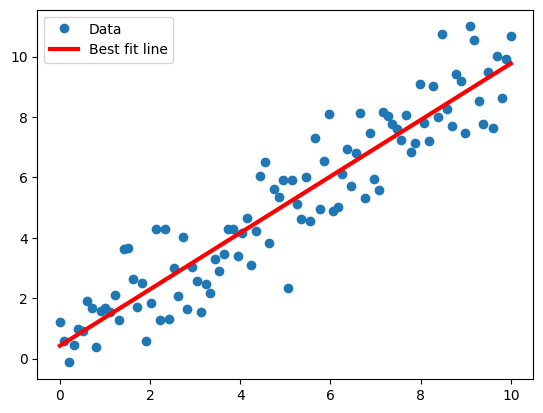

In [2]:
#Matrix Inverse Regression
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 1. Create the data
x_vals = np.linspace(0, 10, 100)
y_vals = x_vals + np.random.normal(0, 1, 100)

# 2. Create design matrix (A) and target matrix (b)
x_vals_column = np.transpose(np.matrix(x_vals))
ones_column = np.transpose(np.matrix(np.repeat(1, 100)))
A = np.column_stack((x_vals_column, ones_column))
b = np.transpose(np.matrix(y_vals))

# 3. Create tensors (float32 for standard precision)
A_tensor = tf.cast(tf.constant(A), tf.float32)
b_tensor = tf.cast(tf.constant(b), tf.float32)

# 4. Matrix inverse solution: x = (AᵀA)⁻¹ * Aᵀb
# In TF 2.x, we use tf.linalg.inv for matrix inversion
tA_A = tf.matmul(tf.transpose(A_tensor), A_tensor)
tA_A_inv = tf.linalg.inv(tA_A)
product = tf.matmul(tA_A_inv, tf.transpose(A_tensor))
solution = tf.matmul(product, b_tensor)

# 5. Extract values directly (no sess.run required)
solution_eval = solution.numpy()
slope = solution_eval[0][0]
y_intercept = solution_eval[1][0]

print(f'Slope: {slope:.4f}')
print(f'Y-Intercept: {y_intercept:.4f}')

# 6. Plot results
best_fit = slope * x_vals + y_intercept
plt.plot(x_vals, y_vals, 'o', label='Data')
plt.plot(x_vals, best_fit, 'r-', label='Best fit line', linewidth=3)
plt.legend(loc='upper left')
plt.show()


slope: 0.9953183591663599
y_intercept: -0.05400448987554862


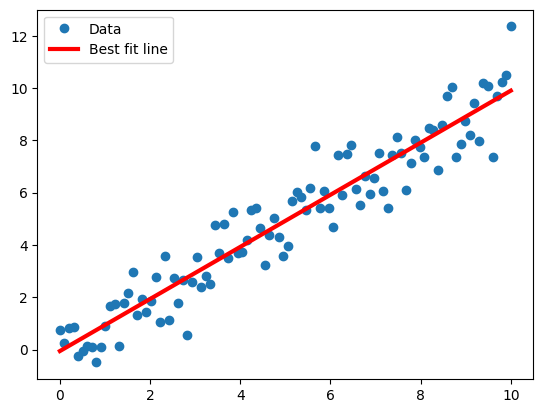

In [3]:
#Decomposition Method
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 1. Create the data
x_vals = np.linspace(0, 10, 100)
y_vals = x_vals + np.random.normal(0, 1, 100)

# 2. Create design matrix (A) and target matrix (b)
x_vals_column = np.transpose(np.matrix(x_vals))
ones_column = np.transpose(np.matrix(np.repeat(1, 100)))
A = np.column_stack((x_vals_column, ones_column))
b = np.transpose(np.matrix(y_vals))

# 3. Create tensors (cast to float64 to match numpy's default)
A_tensor = tf.cast(tf.constant(A), tf.float64)
b_tensor = tf.cast(tf.constant(b), tf.float64)

# 4. Cholesky Decomposition
# tf.cholesky -> tf.linalg.cholesky
tA_A = tf.matmul(tf.transpose(A_tensor), A_tensor)
L = tf.linalg.cholesky(tA_A)

# 5. Solve L*y = t(A)*b
tA_b = tf.matmul(tf.transpose(A_tensor), b_tensor)
# tf.matrix_solve -> tf.linalg.triangular_solve (more efficient for Cholesky)
sol1 = tf.linalg.triangular_solve(L, tA_b, lower=True)

# 6. Solve L' * x = sol1
# Transpose of L is upper triangular
sol2 = tf.linalg.triangular_solve(tf.transpose(L), sol1, lower=False)

# 7. Extract coefficients (Eager execution returns values immediately)
solution_eval = sol2.numpy()
slope = solution_eval[0][0]
y_intercept = solution_eval[1][0]

print(f'slope: {slope}')
print(f'y_intercept: {y_intercept}')

# 8. Get best fit line and plot
best_fit = slope * x_vals + y_intercept

plt.plot(x_vals, y_vals, 'o', label='Data')
plt.plot(x_vals, best_fit, 'r-', label='Best fit line', linewidth=3)
plt.legend(loc='upper left')
plt.show()


Starting L1 Training...
L1 Step #25: A = [3.1577268], b = [0.809448]
L1 Step #50: A = [2.936526], b = [1.7574478]

Starting L2 Training...
L2 Step #25: A = [1.3319557], b = [3.9535265]
L2 Step #50: A = [1.0569338], b = [4.529507]


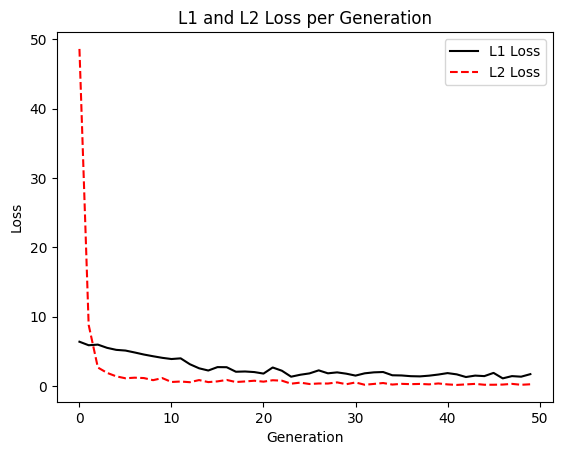

In [4]:
#L1 , L2... Absolute difference, Square of Difference
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn import datasets

# 1. Load the data
iris = datasets.load_iris()
x_vals = np.array([x[3] for x in iris.data], dtype=np.float32)
y_vals = np.array([y[0] for y in iris.data], dtype=np.float32)

# 2. Hyperparameters
batch_size = 25
learning_rate = 0.1 # Reduced from 0.4 for better stability
iterations = 50

# 3. Helper function for training (TF 2.x style)
def train_model(loss_type='l1'):
    # Variables for linear regression
    A = tf.Variable(tf.random.normal(shape=[1, 1]))
    b = tf.Variable(tf.random.normal(shape=[1, 1]))
    optimizer = tf.optimizers.SGD(learning_rate)
    loss_vec = []

    for i in range(iterations):
        # Create random batch
        rand_index = np.random.choice(len(x_vals), size=batch_size)
        rand_x = np.expand_dims(x_vals[rand_index], axis=1)
        rand_y = np.expand_dims(y_vals[rand_index], axis=1)

        with tf.GradientTape() as tape:
            # Model operations
            model_output = tf.add(tf.matmul(rand_x, A), b)

            # Loss functions
            if loss_type == 'l1':
                loss = tf.reduce_mean(tf.abs(rand_y - model_output))
            else: # L2
                loss = tf.reduce_mean(tf.square(rand_y - model_output))

        # Calculate gradients and update variables
        gradients = tape.gradient(loss, [A, b])
        optimizer.apply_gradients(zip(gradients, [A, b]))

        loss_vec.append(loss.numpy())

        if (i + 1) % 25 == 0:
            print(f'{loss_type.upper()} Step #{i+1}: A = {A.numpy()[0]}, b = {b.numpy()[0]}')

    return loss_vec

# 4. Execute training
print("Starting L1 Training...")
loss_vec_l1 = train_model(loss_type='l1')

print("\nStarting L2 Training...")
loss_vec_l2 = train_model(loss_type='l2')

# 5. Plot loss over time
plt.plot(loss_vec_l1, 'k-', label='L1 Loss')
plt.plot(loss_vec_l2, 'r--', label='L2 Loss')
plt.title('L1 and L2 Loss per Generation')
plt.xlabel('Generation')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


Step #100 A = [3.078227] b = [1.7238424] Loss = 0.4243
Step #200 A = [2.7969065] b = [2.1897755] Loss = 0.4246
Step #300 A = [2.4383967] b = [2.6991138] Loss = 0.4162
Step #400 A = [1.9842391] b = [3.3247051] Loss = 0.3837
Step #500 A = [1.3357459] b = [4.1257367] Loss = 0.3411
Step #600 A = [1.0188311] b = [4.5636644] Loss = 0.2909
Step #700 A = [1.0064769] b = [4.5607533] Loss = 0.2577
Step #800 A = [1.0530765] b = [4.608478] Loss = 0.2511
Step #900 A = [1.0170602] b = [4.613234] Loss = 0.2760
Step #1000 A = [1.0255346] b = [4.5996146] Loss = 0.2750


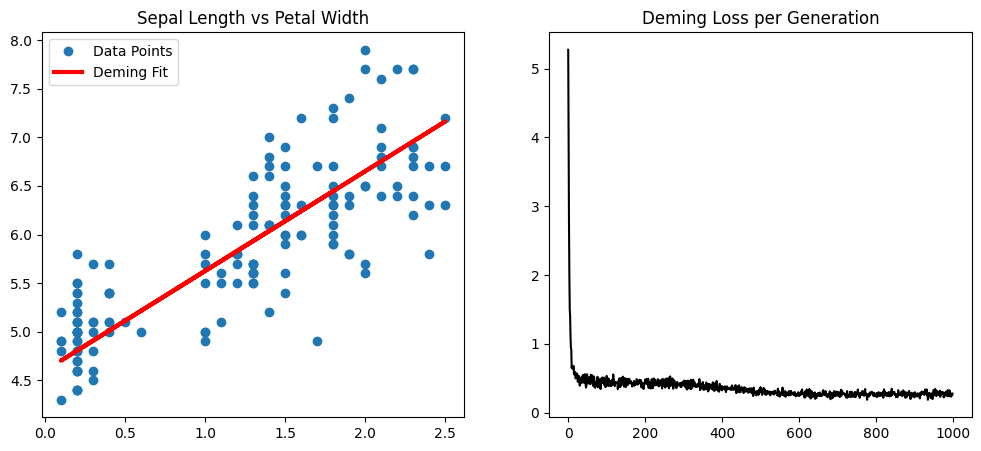

In [5]:
#Deming Regression
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn import datasets

# 1. Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 2. Load the data
iris = datasets.load_iris()
x_vals = np.array([x[3] for x in iris.data], dtype=np.float32)
y_vals = np.array([y[0] for y in iris.data], dtype=np.float32)

# 3. Hyperparameters
batch_size = 50
learning_rate = 0.15
iterations = 1000

# 4. Initialize variables (No placeholders needed)
A = tf.Variable(tf.random.normal(shape=[1, 1]))
b = tf.Variable(tf.random.normal(shape=[1, 1]))
optimizer = tf.optimizers.SGD(learning_rate)

# 5. Training loop
loss_vec = []

for i in range(iterations):
    # Create random batch
    rand_index = np.random.choice(len(x_vals), size=batch_size)
    rand_x = np.transpose([x_vals[rand_index]])
    rand_y = np.transpose([y_vals[rand_index]])

    with tf.GradientTape() as tape:
        # Deming loss: |Ax + b - y| / sqrt(A^2 + 1)
        model_output = tf.add(tf.matmul(rand_x, A), b)
        deming_num = tf.abs(tf.subtract(rand_y, model_output))
        deming_den = tf.sqrt(tf.add(tf.square(A), 1.0))
        loss = tf.reduce_mean(tf.divide(deming_num, deming_den))

    # Calculate and apply gradients
    gradients = tape.gradient(loss, [A, b])
    optimizer.apply_gradients(zip(gradients, [A, b]))

    loss_val = loss.numpy()
    loss_vec.append(loss_val)

    if (i + 1) % 100 == 0:
        print(f'Step #{i+1} A = {A.numpy()[0]} b = {b.numpy()[0]} Loss = {loss_val:.4f}')

# 6. Extract optimal coefficients
slope = A.numpy()[0][0]
y_intercept = b.numpy()[0][0]

# 7. Plot results
best_fit = slope * x_vals + y_intercept

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals, 'o', label='Data Points')
plt.plot(x_vals, best_fit, 'r-', label='Deming Fit', linewidth=3)
plt.title('Sepal Length vs Petal Width')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_vec, 'k-')
plt.title('Deming Loss per Generation')
plt.show()


Step #300 A = [1.9837953] b = [1.1759875]
Loss = 9.685813903808594

Step #600 A = [1.7746425] b = [2.2503064]
Loss = 5.816875457763672

Step #900 A = [1.4620932] b = [3.000945]
Loss = 3.6974124908447266

Step #1200 A = [1.199986] b = [3.571544]
Loss = 2.4246747493743896

Step #1500 A = [1.0011679] b = [4.0083165]
Loss = 1.6993975639343262



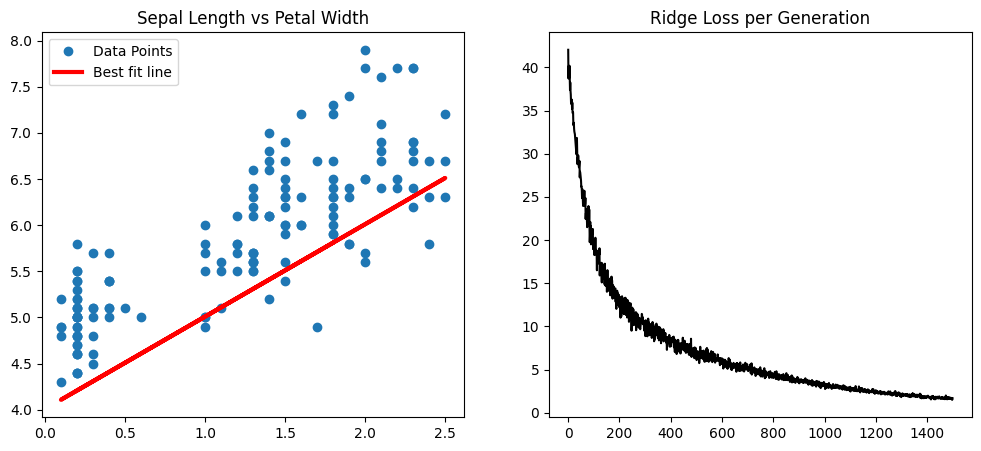

In [6]:
#Lasso Ridge Regression
#Regression if works well for trained data but fails on data not seen before it is overfitting..

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn import datasets

# 1. Configuration
regression_type = 'Ridge'  # Or 'LASSO'
batch_size = 50
learning_rate = 0.001
iterations = 1500
seed = 13

# 2. Reproducibility
np.random.seed(seed)
tf.random.set_seed(seed)

# 3. Load data
iris = datasets.load_iris()
x_vals = np.array([x[3] for x in iris.data], dtype=np.float32)
y_vals = np.array([y[0] for y in iris.data], dtype=np.float32)

# 4. Initialize Variables
A = tf.Variable(tf.random.normal(shape=(1, 1)))
b = tf.Variable(tf.random.normal(shape=(1, 1)))
optimizer = tf.keras.optimizers.SGD(learning_rate)

loss_vec = []

# 5. Training Loop
for i in range(iterations):
    rand_index = np.random.choice(len(x_vals), size=batch_size)
    rand_x = np.atleast_2d(x_vals[rand_index]).T
    rand_y = np.atleast_2d(y_vals[rand_index]).T

    with tf.GradientTape() as tape:
        # Model: y = Ax + b
        model_output = tf.add(tf.matmul(rand_x, A), b)
        mse_loss = tf.reduce_mean(tf.square(rand_y - model_output))

        if regression_type == 'LASSO':
            # Soft-approximation of Heaviside step for LASSO
            lasso_param = 0.9
            heavyside_step = 1. / (1. + tf.exp(-50. * (A - lasso_param)))
            regularization = heavyside_step * 99.
            loss = mse_loss + regularization
        else: # Ridge
            ridge_param = 1.0
            ridge_loss = tf.reduce_mean(tf.square(A))
            loss = mse_loss + (ridge_param * ridge_loss)

    # Apply Gradients
    gradients = tape.gradient(loss, [A, b])
    optimizer.apply_gradients(zip(gradients, [A, b]))

    current_loss = loss.numpy()
    # Flatten loss for recording
    loss_vec.append(np.array(current_loss).flatten()[0])

    if (i + 1) % 300 == 0:
        print(f'Step #{i+1} A = {A.numpy().flatten()} b = {b.numpy().flatten()}')
        print(f'Loss = {current_loss}\n')

# 6. Extract Results
slope = A.numpy()[0][0]
y_intercept = b.numpy()[0][0]
best_fit = slope * x_vals + y_intercept

# 7. Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals, 'o', label='Data Points')
plt.plot(x_vals, best_fit, 'r-', label='Best fit line', linewidth=3)
plt.title('Sepal Length vs Petal Width')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_vec, 'k-')
plt.title(f'{regression_type} Loss per Generation')
plt.show()
